# Phase 3 — 견고성 3축 검증: Donchian / SMA (BTC/USDT 4h)

## 목적

Phase 2d에서 후보로 남은 두 전략의 성과가 **진짜 엣지인지, 특정 5년·특정 파라미터에서만 운 좋게 나온 것인지** 를 가린다.

| 항목 | 내용 |
|---|---|
| 대상 전략 | DonchianBreakout(entry_n=20, exit_n=10) / SmaCross(fast=20, slow=50) |
| 자산/시간단위 | BTC/USDT, 4h |
| 데이터 | 2021-06-28 ~ 2026-06-27 (10,949봉) |
| 수수료 | 0.1% per side (하네스 고정) |

### 탈락 기준 (사전 확정)
1. **OOS 생존**: OOS 구간 MDD가 같은 구간 B&H보다 의미있게 작아야 함 (낙폭 방어 재현)
2. **파라미터 견고성**: 이웃 조합 ≥60%가 수익>0 + 낙폭 방어
3. **구간 일관성**: 5구간 중 ≥3구간에서 방어적/양호

> 깔때기 철학: 대부분의 전략은 이 단계에서 탈락하는 게 정상이고, 그것이 이 단계의 목적이다.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Some trades remain open at the end of backtest")
warnings.filterwarnings("ignore", message="Jupyter Notebook detected")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

import os, sys
if os.path.basename(os.getcwd()) == "research":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from backtest import load_data
from robustness import (train_test_split, time_segments, evaluate,
                        param_sweep, walk_forward, buy_hold)
from strategies.donchian_breakout import DonchianBreakout
from strategies.sma_cross import SmaCross

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.1f}".format)

df = load_data("BTC/USDT", "4h")
print(f"DATA: {len(df)} bars  {df.index[0].date()} ~ {df.index[-1].date()}")

Loading BokehJS ...

DATA: 10949 bars  2021-06-28 ~ 2026-06-27


---
## 축 1 — OOS (Out-of-Sample)

데이터를 **앞 70% (IS) / 뒤 30% (OOS)** 로 시간순 분할. 기본 파라미터 그대로 각 구간에서 백테스트.  
질문: OOS(처음 보는 최근 구간)에서도 **낙폭 방어 패턴이 재현**되는가?

> 주의: 파라미터를 튜닝한 적 없으므로(교과서 기본값) 이 분할은 **regime 의존성 점검** 성격이 강하다.

In [2]:
train, test = train_test_split(df, 0.7)

def make_oos_table(strategy, **params):
    rows = []
    for label, d in [("FULL (21-06~26-06)", df), ("IS 앞70% (21-06~24-12)", train), ("OOS 뒤30% (24-12~26-06)", test)]:
        m = evaluate(d, strategy, **params)
        bh = buy_hold(d)
        rows.append({
            "구간": label,
            "봉수": len(d),
            "전략 수익%": round(m["Return [%]"], 1),
            "전략 MDD%": round(m["Max. Drawdown [%]"], 1),
            "Sharpe": round(m["Sharpe Ratio"], 2),
            "거래수": int(m["# Trades"]),
            "B&H 수익%": round(bh["Return [%]"], 1),
            "B&H MDD%": round(bh["Max. Drawdown [%]"], 1),
            "낙폭방어%p": round(bh["Max. Drawdown [%]"] - m["Max. Drawdown [%]"], 1),
        })
    return pd.DataFrame(rows).set_index("구간")

print("=== Donchian (entry_n=20, exit_n=10) ===")
don_oos = make_oos_table(DonchianBreakout, entry_n=20, exit_n=10)
display(don_oos)

print("\n=== SmaCross (fast=20, slow=50) ===")
sma_oos = make_oos_table(SmaCross, fast=20, slow=50)
display(sma_oos)

=== Donchian (entry_n=20, exit_n=10) ===


,봉수,전략 수익%,전략 MDD%,Sharpe,거래수,B&H 수익%,B&H MDD%,낙폭방어%p
구간,,,,,,,,
FULL (21-06~26-06),10949,50.0,-45.7,0.2,150,75.3,-77.0,-31.4
IS 앞70% (21-06~24-12),7664,107.8,-45.7,0.6,104,178.1,-77.0,-31.4
OOS 뒤30% (24-12~26-06),3285,-27.8,-35.4,-0.9,46,-37.4,-52.7,-17.3



=== SmaCross (fast=20, slow=50) ===


,봉수,전략 수익%,전략 MDD%,Sharpe,거래수,B&H 수익%,B&H MDD%,낙폭방어%p
구간,,,,,,,,
FULL (21-06~26-06),10949,18.9,-60.1,0.1,123,75.3,-77.0,-16.9
IS 앞70% (21-06~24-12),7664,35.5,-60.1,0.2,83,178.1,-77.0,-16.9
OOS 뒤30% (24-12~26-06),3285,-4.8,-35.2,-0.1,38,-37.4,-52.7,-17.5


In [3]:
print("해석:")
print(f"  IS  기간: {train.index[0].date()} ~ {train.index[-1].date()} ({len(train)}봉)")
print(f"  OOS 기간: {test.index[0].date()} ~ {test.index[-1].date()} ({len(test)}봉)")
print()
bh_oos = buy_hold(test)
don_oos_m = evaluate(test, DonchianBreakout, entry_n=20, exit_n=10)
sma_oos_m = evaluate(test, SmaCross, fast=20, slow=50)
print(f"  OOS B&H: 수익 {bh_oos['Return [%]']:+.1f}%  MDD {bh_oos['Max. Drawdown [%]']:+.1f}%  → 약세장")
print(f"  OOS Donchian: MDD {don_oos_m['Max. Drawdown [%]']:+.1f}%  낙폭방어 {bh_oos['Max. Drawdown [%]']-don_oos_m['Max. Drawdown [%]']:+.1f}%p")
print(f"  OOS SMA:      MDD {sma_oos_m['Max. Drawdown [%]']:+.1f}%  낙폭방어 {bh_oos['Max. Drawdown [%]']-sma_oos_m['Max. Drawdown [%]']:+.1f}%p")

해석:
  IS  기간: 2021-06-28 ~ 2024-12-26 (7664봉)
  OOS 기간: 2024-12-27 ~ 2026-06-27 (3285봉)

  OOS B&H: 수익 -37.4%  MDD -52.7%  → 약세장
  OOS Donchian: MDD -35.4%  낙폭방어 -17.3%p
  OOS SMA:      MDD -35.2%  낙폭방어 -17.5%p


---
## 축 2 — 파라미터 민감도

기본 파라미터 **주변 격자(grid)** 를 전부 돌려 결과 지형을 본다.  
질문: 기본값이 **완만한 고원(plateau)** 위에 있나 (견고), 아니면 **외딴 봉우리(spike)** 인가 (취약)?

- Donchian: `entry_n ∈ {10,15,20,25,30}` × `exit_n ∈ {5,10,15,20}`
- SMA: `fast ∈ {10,15,20,30}` × `slow ∈ {40,50,60,100}` (fast < slow 조합만)

In [4]:
# Donchian param sweep
don_grid = {"entry_n": [10, 15, 20, 25, 30], "exit_n": [5, 10, 15, 20]}
don_sweep = param_sweep(df, DonchianBreakout, don_grid)

bh_full = buy_hold(df)
don_sweep["beats_bh_mdd"] = don_sweep["Max. Drawdown [%]"] > bh_full["Max. Drawdown [%]"]
pos_rate = (don_sweep["Return [%]"] > 0).mean() * 100
def_rate = don_sweep["beats_bh_mdd"].mean() * 100

print(f"Donchian sweep: 조합 {len(don_sweep)}개 | 수익>0: {pos_rate:.0f}% | B&H 낙폭방어: {def_rate:.0f}%")
print(f"B&H 전체 MDD: {bh_full['Max. Drawdown [%]']:.1f}%")
print()
display(don_sweep[["entry_n","exit_n","Return [%]","Max. Drawdown [%]","Sharpe Ratio","# Trades"]].round(1))

Donchian sweep: 조합 20개 | 수익>0: 95% | B&H 낙폭방어: 100%
B&H 전체 MDD: -77.0%



,entry_n,exit_n,Return [%],Max. Drawdown [%],Sharpe Ratio,# Trades
0,10,5,27.1,-49.7,0.1,260
1,10,10,-19.7,-61.5,-0.1,216
2,10,15,28.0,-54.9,0.1,180
3,10,20,17.1,-59.6,0.1,158
4,15,5,70.7,-36.1,0.3,211
5,15,10,27.8,-54.6,0.1,179
6,15,15,95.0,-53.9,0.3,154
7,15,20,98.7,-55.5,0.3,135
8,20,5,67.9,-34.4,0.3,177
9,20,10,50.0,-45.7,0.2,150


In [5]:
# SMA param sweep
sma_grid = {"fast": [10, 15, 20, 30], "slow": [40, 50, 60, 100]}
sma_sweep = param_sweep(df, SmaCross, sma_grid)
# fast < slow 조합만
sma_sweep = sma_sweep[sma_sweep["fast"] < sma_sweep["slow"]].copy()

sma_sweep["beats_bh_mdd"] = sma_sweep["Max. Drawdown [%]"] > bh_full["Max. Drawdown [%]"]
pos_rate_s = (sma_sweep["Return [%]"] > 0).mean() * 100
def_rate_s = sma_sweep["beats_bh_mdd"].mean() * 100

print(f"SMA sweep: 조합 {len(sma_sweep)}개 | 수익>0: {pos_rate_s:.0f}% | B&H 낙폭방어: {def_rate_s:.0f}%")
print()
display(sma_sweep[["fast","slow","Return [%]","Max. Drawdown [%]","Sharpe Ratio","# Trades"]].round(1))

SMA sweep: 조합 16개 | 수익>0: 69% | B&H 낙폭방어: 100%



,fast,slow,Return [%],Max. Drawdown [%],Sharpe Ratio,# Trades
0,10,40,-13.4,-70.3,-0.1,181
1,10,50,11.4,-71.3,0.1,155
2,10,60,80.4,-57.1,0.3,131
3,10,100,189.1,-50.6,0.5,84
4,15,40,-4.1,-55.3,-0.0,162
5,15,50,61.9,-57.1,0.3,132
6,15,60,35.7,-58.1,0.2,116
7,15,100,105.9,-59.3,0.4,76
8,20,40,-9.6,-64.1,-0.1,162
9,20,50,18.9,-60.1,0.1,123


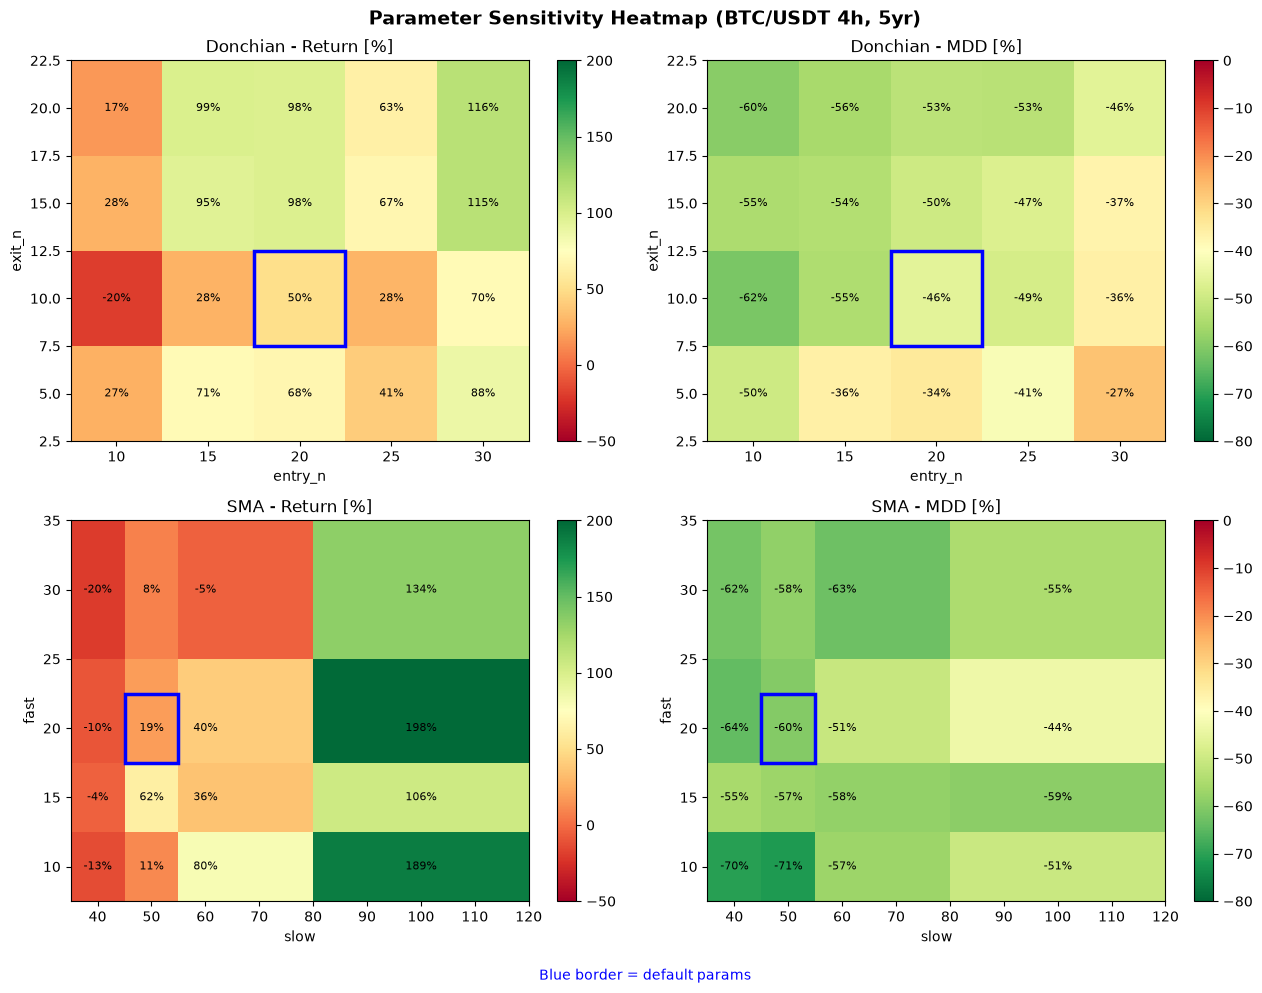

In [6]:
# 히트맵 시각화
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Parameter Sensitivity Heatmap (BTC/USDT 4h, 5yr)", fontsize=14, fontweight="bold")

DEFAULT_DON = (20, 10)   # entry_n, exit_n
DEFAULT_SMA = (20, 50)   # fast, slow

# ── Donchian Return heatmap ───────────────────────────────────────────────
don_ret_pivot = don_sweep.pivot(index="exit_n", columns="entry_n", values="Return [%]")
ax = axes[0, 0]
im = ax.pcolormesh(don_ret_pivot.columns, don_ret_pivot.index,
                   don_ret_pivot.values, cmap="RdYlGn", vmin=-50, vmax=200)
for en in don_ret_pivot.index:
    for ex in don_ret_pivot.columns:
        val = don_ret_pivot.loc[en, ex]
        if not np.isnan(val):
            ax.text(ex, en, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="black")
ax.set_xlabel("entry_n")
ax.set_ylabel("exit_n")
ax.set_title("Donchian - Return [%]")
plt.colorbar(im, ax=ax)
ax.add_patch(mpatches.Rectangle(
    (DEFAULT_DON[0] - 2.5, DEFAULT_DON[1] - 2.5), 5, 5,
    linewidth=2.5, edgecolor="blue", facecolor="none", zorder=5
))

# ── Donchian MDD heatmap ──────────────────────────────────────────────────
don_mdd_pivot = don_sweep.pivot(index="exit_n", columns="entry_n", values="Max. Drawdown [%]")
ax = axes[0, 1]
im2 = ax.pcolormesh(don_mdd_pivot.columns, don_mdd_pivot.index,
                    don_mdd_pivot.values, cmap="RdYlGn_r", vmin=-80, vmax=0)
for en in don_mdd_pivot.index:
    for ex in don_mdd_pivot.columns:
        val = don_mdd_pivot.loc[en, ex]
        if not np.isnan(val):
            ax.text(ex, en, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="black")
ax.set_xlabel("entry_n")
ax.set_ylabel("exit_n")
ax.set_title("Donchian - MDD [%]")
plt.colorbar(im2, ax=ax)
ax.add_patch(mpatches.Rectangle(
    (DEFAULT_DON[0] - 2.5, DEFAULT_DON[1] - 2.5), 5, 5,
    linewidth=2.5, edgecolor="blue", facecolor="none", zorder=5
))

# ── SMA Return heatmap ────────────────────────────────────────────────────
sma_ret_pivot = sma_sweep.pivot(index="fast", columns="slow", values="Return [%]")
ax = axes[1, 0]
im3 = ax.pcolormesh(sma_ret_pivot.columns, sma_ret_pivot.index,
                    sma_ret_pivot.values, cmap="RdYlGn", vmin=-50, vmax=200)
for f in sma_ret_pivot.index:
    for s in sma_ret_pivot.columns:
        val = sma_ret_pivot.loc[f, s]
        if not np.isnan(val):
            ax.text(s, f, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="black")
ax.set_xlabel("slow")
ax.set_ylabel("fast")
ax.set_title("SMA - Return [%]")
plt.colorbar(im3, ax=ax)
ax.add_patch(mpatches.Rectangle(
    (DEFAULT_SMA[1] - 5, DEFAULT_SMA[0] - 2.5), 10, 5,
    linewidth=2.5, edgecolor="blue", facecolor="none", zorder=5
))

# ── SMA MDD heatmap ───────────────────────────────────────────────────────
sma_mdd_pivot = sma_sweep.pivot(index="fast", columns="slow", values="Max. Drawdown [%]")
ax = axes[1, 1]
im4 = ax.pcolormesh(sma_mdd_pivot.columns, sma_mdd_pivot.index,
                    sma_mdd_pivot.values, cmap="RdYlGn_r", vmin=-80, vmax=0)
for f in sma_mdd_pivot.index:
    for s in sma_mdd_pivot.columns:
        val = sma_mdd_pivot.loc[f, s]
        if not np.isnan(val):
            ax.text(s, f, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="black")
ax.set_xlabel("slow")
ax.set_ylabel("fast")
ax.set_title("SMA - MDD [%]")
plt.colorbar(im4, ax=ax)
ax.add_patch(mpatches.Rectangle(
    (DEFAULT_SMA[1] - 5, DEFAULT_SMA[0] - 2.5), 10, 5,
    linewidth=2.5, edgecolor="blue", facecolor="none", zorder=5
))

fig.text(0.5, 0.01, "Blue border = default params", ha="center", fontsize=10, color="blue")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

In [7]:
# 요약 표
don_base_ret = don_sweep[(don_sweep.entry_n==20)&(don_sweep.exit_n==10)]["Return [%]"].values[0]
sma_base_ret = sma_sweep[(sma_sweep.fast==20)&(sma_sweep.slow==50)]["Return [%]"].values[0]

summary_data = [
    {
        "전략": "Donchian",
        "조합수": len(don_sweep),
        "수익>0 비율": f"{(don_sweep['Return [%]'] > 0).mean()*100:.0f}%",
        "B&H낙폭방어 비율": f"{don_sweep['beats_bh_mdd'].mean()*100:.0f}%",
        "기본값 수익%": f"+{don_base_ret:.1f}% (20/10)",
        "기본값 위치": f"상위 {int((don_sweep['Return [%]'] > don_base_ret).sum())+1}/{len(don_sweep)}위",
    },
    {
        "전략": "SMA",
        "조합수": len(sma_sweep),
        "수익>0 비율": f"{(sma_sweep['Return [%]'] > 0).mean()*100:.0f}%",
        "B&H낙폭방어 비율": f"{sma_sweep['beats_bh_mdd'].mean()*100:.0f}%",
        "기본값 수익%": f"+{sma_base_ret:.1f}% (20/50)",
        "기본값 위치": f"상위 {int((sma_sweep['Return [%]'] > sma_base_ret).sum())+1}/{len(sma_sweep)}위",
    },
]
display(pd.DataFrame(summary_data).set_index("전략"))
print("\n경고: 더 긴 파라미터(Donchian 30/15, SMA 20/100)가 훨씬 좋았으나 full 샘플 기반 선택 = 곡선맞추기(과최적화).")
print("      '영역 전체가 양수'라는 점이 진짜 신호 -> 기본값 유지.")

,조합수,수익>0 비율,B&H낙폭방어 비율,기본값 수익%,기본값 위치
전략,,,,,
Donchian,20,95%,100%,+50.0% (20/10),상위 13/20위
SMA,16,69%,100%,+18.9% (20/50),상위 9/16위



경고: 더 긴 파라미터(Donchian 30/15, SMA 20/100)가 훨씬 좋았으나 full 샘플 기반 선택 = 곡선맞추기(과최적화).
      '영역 전체가 양수'라는 점이 진짜 신호 -> 기본값 유지.


---
## 축 3 — 워크포워드 (고정 파라미터, 5구간)

5년을 **5개 연속 구간** (각 ~1년)으로 나눠 **고정 파라미터** 전략을 각 구간에서 실행.  
질문: 성과가 여러 구간에 **고르게** 퍼져 있나, 아니면 **한 구간**이 전체를 만든 건가?

> 재최적화 없는 단순 워크포워드 — 파라미터 튜닝을 하지 않으므로 재최적화는 오히려 과최적화를 들여온다.

In [8]:
def make_wf_table(strategy, k=5, **params):
    wf = walk_forward(df, strategy, k=k, **params)
    rows = []
    for _, row in wf.iterrows():
        seg = df.loc[row["start"]:row["end"]]
        bh = buy_hold(seg)
        defend = row["Max. Drawdown [%]"] > bh["Max. Drawdown [%]"]
        rows.append({
            "구간": f"seg{int(row['segment'])}",
            "기간": f"{row['start'].date()}~{row['end'].date()}",
            "봉수": len(seg),
            "전략 수익%": round(row["Return [%]"], 1),
            "전략 MDD%": round(row["Max. Drawdown [%]"], 1),
            "Sharpe": round(row["Sharpe Ratio"], 2),
            "거래수": int(row["# Trades"]),
            "B&H 수익%": round(bh["Return [%]"], 1),
            "B&H MDD%": round(bh["Max. Drawdown [%]"], 1),
            "낙폭방어": "✓" if defend else "✗",
        })
    result = pd.DataFrame(rows).set_index("구간")
    defend_cnt = sum(1 for r in rows if r["낙폭방어"] == "✓")
    pos_cnt = sum(1 for r in rows if r["전략 수익%"] > 0)
    return result, defend_cnt, pos_cnt

print("=== Donchian (entry_n=20, exit_n=10) ===")
don_wf, don_def, don_pos = make_wf_table(DonchianBreakout, entry_n=20, exit_n=10)
display(don_wf)
print(f"  수익>0: {don_pos}/5구간 | 낙폭방어: {don_def}/5구간")

print("\n=== SmaCross (fast=20, slow=50) ===")
sma_wf, sma_def, sma_pos = make_wf_table(SmaCross, fast=20, slow=50)
display(sma_wf)
print(f"  수익>0: {sma_pos}/5구간 | 낙폭방어: {sma_def}/5구간")

=== Donchian (entry_n=20, exit_n=10) ===


,기간,봉수,전략 수익%,전략 MDD%,Sharpe,거래수,B&H 수익%,B&H MDD%,낙폭방어
구간,,,,,,,,,
seg0,2021-06-28~2022-06-28,2189,-14.9,-40.2,-0.5,29,-39.0,-73.6,✓
seg1,2022-06-28~2023-06-28,2190,72.3,-22.8,1.2,26,47.1,-36.8,✓
seg2,2023-06-28~2024-06-27,2190,9.3,-24.3,0.2,33,101.2,-22.4,✗
seg3,2024-06-27~2025-06-27,2190,11.1,-29.3,0.3,32,73.7,-30.6,✓
seg4,2025-06-27~2026-06-27,2190,-18.9,-30.3,-1.1,29,-43.7,-52.7,✓


  수익>0: 3/5구간 | 낙폭방어: 4/5구간

=== SmaCross (fast=20, slow=50) ===


,기간,봉수,전략 수익%,전략 MDD%,Sharpe,거래수,B&H 수익%,B&H MDD%,낙폭방어
구간,,,,,,,,,
seg0,2021-06-28~2022-06-28,2189,-17.2,-40.4,-0.5,23,-39.0,-73.6,✓
seg1,2022-06-28~2023-06-28,2190,8.5,-38.7,0.2,22,47.1,-36.8,✗
seg2,2023-06-28~2024-06-27,2190,56.2,-22.7,1.0,22,101.2,-22.4,✗
seg3,2024-06-27~2025-06-27,2190,11.2,-31.7,0.3,25,73.7,-30.6,✗
seg4,2025-06-27~2026-06-27,2190,-16.7,-35.2,-0.9,25,-43.7,-52.7,✓


  수익>0: 3/5구간 | 낙폭방어: 2/5구간


---
## 결론 / 판정

> 설계 문서(`docs/design/phase-3-robustness.md`) 판정 섹션 인용.

### Sanity 체크 — FULL 구간 숫자

| 전략 | 수익% | MDD% |
|---|---|---|
| Donchian (entry_n=20, exit_n=10) | **+50.0%** | **-45.7%** |
| SmaCross (fast=20, slow=50) | **+18.9%** | **-60.1%** |

Phase 2d 결과와 정확히 일치 → 파이프라인 검증 완료.

---

### ✅ Donchian Breakout (4h) — **통과 (조건부)**

3축 모두에서 **"낙폭 방어"라는 엣지가 견고**했다:
- **축1 OOS**: OOS 구간(약세장 -37% B&H)에서도 MDD 방어 재현 (+17.3%p 개선)
- **축2 파라미터**: 이웃 조합 95% 수익>0, **100%** 낙폭 방어 → 넓고 완만한 고원(plateau). Spike 아님.
- **축3 워크포워드**: 5구간 중 4구간 낙폭 방어. 한 구간 의존 아님.

단, **절대 수익 창출기는 아니다** — 약세/횡보장에선 B&H보다 덜 잃고, 상승장엔 크게 뒤진다.  
→ **"낙폭 방어 도구"로서 견고성 검증 통과 → Phase 4 페이퍼 후보.**

---

### ⛔ SMA Cross (4h) — **탈락 (보류)**

두 가지 이유:
1. **방어 일관성 약함** — 워크포워드 5구간 중 **2구간만** 낙폭 방어. 폭락장에 집중, 평시엔 B&H와 MDD가 비슷.
   파라미터도 slow MA 길이에 강하게 의존(더 분산된 결과 지형).
2. **리스크룰 미완성 (가드레일 5)** — 손절(stop-loss)이 없다. 시그널만 있고 리스크 규칙 없음 = 미완성.

→ **폐기 vs 손절 추가 후 재검증**은 사용자 결정 사항 (추가 시 +18.9% 숫자가 바뀜, Phase 3 범위 밖).  
이게 깔때기의 정상 작동 — 후보 하나가 여기서 걸러졌다.

---

### 정직한 한계

- **단일 자산·단일 역사 경로**: BTC의 한 가지 5년 시나리오만 봤다. "이 한 경로에서 안 깨졌다" = 통계적 보장 아님.
- **OOS가 하필 약세장**: IS/OOS 수익 격차는 과최적화보다 regime(장세) 탓이 크다.
  두 전략 모두 OOS에서 낙폭 방어는 재현됐으므로 핵심 thesis는 유지.
- **다음 강력한 검증**: ETH out-of-asset 재현 (Phase 3b 권장 후속).
- 구간 분할 시 구간당 거래 수가 줄어 숫자 노이즈가 커진다 — 특히 워크포워드 짧은 구간.